In [1]:
## preprocessing
%load_ext autoreload
%autoreload 2
import os
import random
import numpy as np
import pandas as pd
import torch
import sys
import matplotlib as plt
from tqdm import tqdm
current_pth = os.path.abspath('../')
print(current_pth)
sys.path.append(current_pth)
from utils.sequence_process import SeqProcessConfig, HaplotypeSeqProcessor,validate_df
from utils.data_preprocess import  drop_nan_missing_values,drop_wilde_type,renormalize
from utils.data_preprocess import transform_genseq_upper
from utils.utilities import ReaderWriter, report_available_cuda_devices,get_device
from utils.data_preprocess import create_directory
from proportion_model.src.predict_model import BEDICT_EncEnc_HaplotypeModel

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
/Users/amina/repositories/public_repo/BEDICT-V2


In [2]:
pwd

'/Users/amina/repositories/public_repo/BEDICT-V2/notebooks'

In [5]:
editor_name = 'ABEmax-SpRY'
in_vitro = True
lib_name =''
input_type ='protospacer_PAM'
num_runs = 3
mRNA = False


#data_name = 'Endogenous_targets_for_prediction'
#data_name = 'KM_SpCas9-ABEmax_v2'
data_name = 'DeepABE_ABEmax_Train_df_for_BEDICT_pred_df'
data_pth = os.path.abspath('../')
data_dir = create_directory(os.path.join(data_pth, 'dataset'))
df = pd.read_excel(os.path.join(data_dir,f'{data_name}.xlsx'),
                 header=0)


In [6]:
df

,ID,refseq,PAM
0,HT_ABEmax_1,AAAAAAAAAAAAAAAAAAAA,AGGG
1,HT_ABEmax_2,AAAGTAATTCACTTACAGTC,TGGC
2,HT_ABEmax_3,AAGGATACAGTTTCTGTAAG,TGGA
3,HT_ABEmax_4,AAGTTGTCTATAGCTTGCCT,CGGG
4,HT_ABEmax_5,ACCTGACCTGCTCTGTGTCC,TGGG
5,HT_ABEmax_6,ACGTACAGGCCCCTGTCATT,GGGG
6,HT_ABEmax_7,AGACAAGCTTGCTATTCCAA,AGGT
7,HT_ABEmax_8,AGATCGTACATGTTCACCGG,AGGC
8,HT_ABEmax_9,AGCCACCACCTAGAATCGAA,AGGG
9,HT_ABEmax_10,AGCGGGGTCACAAGAAGCCT,AGGA


In [7]:
df.rename(columns={'rname':'ID'}, inplace=True)
df.rename(columns={'refseq':'Reference'}, inplace=True)
#df.rename(columns={'seq':'Outcome'}, inplace=True)
#df.rename(columns={'refseq_pam':'PAM'}, inplace=True)
df = transform_genseq_upper(df, [ 'Reference','PAM' ])

                   
df

,ID,Reference,PAM
0,HT_ABEmax_1,AAAAAAAAAAAAAAAAAAAA,AGGG
1,HT_ABEmax_2,AAAGTAATTCACTTACAGTC,TGGC
2,HT_ABEmax_3,AAGGATACAGTTTCTGTAAG,TGGA
3,HT_ABEmax_4,AAGTTGTCTATAGCTTGCCT,CGGG
4,HT_ABEmax_5,ACCTGACCTGCTCTGTGTCC,TGGG
5,HT_ABEmax_6,ACGTACAGGCCCCTGTCATT,GGGG
6,HT_ABEmax_7,AGACAAGCTTGCTATTCCAA,AGGT
7,HT_ABEmax_8,AGATCGTACATGTTCACCGG,AGGC
8,HT_ABEmax_9,AGCCACCACCTAGAATCGAA,AGGG
9,HT_ABEmax_10,AGCGGGGTCACAAGAAGCCT,AGGA


In [8]:
#'''
# define column names pointers to use throughout, tseq_col and outcome_col would be modified if we need to use diffferent input outputs
id_col = 'ID' # sequnce id column name
#outcome_prop_col = ['Proportion','absolute_efficiency']  # propotion of edits column name  
df = df.copy()


if input_type == 'protospacer':
    extended_df = df
    tseq_col = 'Reference' # target sequence (wild-type) column name
    #outcome_col = 'Outcome' # edit sequence (i.e. edited outcome sequence) column name  
    
elif input_type == 'protospacer_PAM':
    protospacer_PAM =pd.DataFrame(df['Reference'] + df['PAM'])
    protospacer_PAM.columns = ['protospacer_PAM']
    #output_PAM =pd.DataFrame(df['Outcome'] + df['PAM'])
    #output_PAM.columns = ['Outcome_PAM']
    extended_df = pd.concat([df,protospacer_PAM],axis=1)
    tseq_col = 'protospacer_PAM' # target sequence (wild-type) column name
    #outcome_col = 'Outcome_PAM' # edit sequence (i.e. edited outcome sequence) column name 
    
    
elif input_type == 'protospacer_PAM_overhangs':
    df_left = pd.DataFrame({'refseq_leftoverhang': df['refseq_leftoverhang'].str[-k:]})
    df_right = pd.DataFrame({'refseq_rightoverhang': df['refseq_rightoverhang'].str[:k]})
    protospacer_PAM =pd.DataFrame(df_left['refseq_leftoverhang']+ df['Reference'] + df['PAM']+ df_right['refseq_rightoverhang'])
    protospacer_PAM.columns = ['protospacer_PAM_overhangs']
    #output_PAM =pd.DataFrame(df_left['refseq_leftoverhang'] + df['PAM']+df_right['refseq_rightoverhang'])
    #output_PAM.columns = ['Outcome_PAM_overhangs']
    extended_df = pd.concat([df,protospacer_PAM],axis=1)
    tseq_col = 'protospacer_PAM_overhangs' # target sequence (wild-type) column name
    #outcome_col = 'Outcome_PAM_overhangs' # edit sequence (i.e. edited outcome sequence) column name
    
else:
    print('specify the input type')

print(tseq_col)
#df = extended_df.iloc[:2].copy()
df = extended_df.copy()
df
#'''

protospacer_PAM


,ID,Reference,PAM,protospacer_PAM
0,HT_ABEmax_1,AAAAAAAAAAAAAAAAAAAA,AGGG,AAAAAAAAAAAAAAAAAAAAAGGG
1,HT_ABEmax_2,AAAGTAATTCACTTACAGTC,TGGC,AAAGTAATTCACTTACAGTCTGGC
2,HT_ABEmax_3,AAGGATACAGTTTCTGTAAG,TGGA,AAGGATACAGTTTCTGTAAGTGGA
3,HT_ABEmax_4,AAGTTGTCTATAGCTTGCCT,CGGG,AAGTTGTCTATAGCTTGCCTCGGG
4,HT_ABEmax_5,ACCTGACCTGCTCTGTGTCC,TGGG,ACCTGACCTGCTCTGTGTCCTGGG
5,HT_ABEmax_6,ACGTACAGGCCCCTGTCATT,GGGG,ACGTACAGGCCCCTGTCATTGGGG
6,HT_ABEmax_7,AGACAAGCTTGCTATTCCAA,AGGT,AGACAAGCTTGCTATTCCAAAGGT
7,HT_ABEmax_8,AGATCGTACATGTTCACCGG,AGGC,AGATCGTACATGTTCACCGGAGGC
8,HT_ABEmax_9,AGCCACCACCTAGAATCGAA,AGGG,AGCCACCACCTAGAATCGAAAGGG
9,HT_ABEmax_10,AGCGGGGTCACAAGAAGCCT,AGGA,AGCGGGGTCACAAGAAGCCTAGGA


## proportional model prediction

In [9]:
# create a directory where we dump the predictions of the models
#csv_dir = create_directory(os.path.join(current_pth, 'sample_data', 'predictions'))
report_available_cuda_devices()
# instantiate a device using the only one available :P
device = get_device(True, 0)
editor_name

no GPU devices available!!


'ABEmax-SpRY'

In [10]:
# define sequence processor config
target_conv_nucl = {'ABEmax-NG':('A', 'G'),'ABE8e-NG':('A', 'G'), 'ABE8e-SpCas9':('A', 'G'), 'ABE8e-SpRY':('A', 'G'), 'ABEmax-SpCas9':('A','G'),'ABEmax-SpRY':('A', 'G'),}
seqconfig = SeqProcessConfig(24, (1,24), (1,20), 1)
seq_processor = HaplotypeSeqProcessor(editor_name, target_conv_nucl[editor_name], seqconfig)

+--------------------------------------+-------------+
|             Description              |    Value    |
+--------------------------------------+-------------+
|             Base editor              | ABEmax-SpRY |
|          Target nucleotide           |      A      |
|        Conversion nucleotide         |      G      |
| Maximum number of targets considered |      8      |
+--------------------------------------+-------------+
+------------------------------------------------+-------+
|           Sequence processing Config           | Value |
+------------------------------------------------+-------+
|                sequence length                 |   24  |
|    sequence start index (0-based indexing)     |   0   |
|     sequence end index (0-based indexing)      |   23  |
| editable window start index (0-based indexing) |   0   |
|  editable window end index (0-based indexing)  |   19  |
|             offset start numbering             |   1   |
|              offset end num

In [11]:
bedict = BEDICT_EncEnc_HaplotypeModel(seq_processor, seqconfig, device)

In [13]:
num_runs = 3
if in_vitro:
    model_path = current_pth +  f'/proportion_model/output/experiment_run_proportions_encenc_two_model/{editor_name}_proportions_encenc_two_model/'+ input_type + '/exp_version_0/train_val/'
    #proportion = []
elif mRNA:
     model_path = current_pth +  f'/proportion_model/output/experiment_run_proportions_encenc_two_model/mRNA/{editor_name}_proportions_encenc_two_model/'+ input_type + '/exp_version_0/train_val/'
    #proportion = []
else:
    model_path = current_pth +  '/proportion_model/output/experiment_run_proportions_encenc_two_model/'+lib_name+ '/ABE8e-SpCas9_proportions_encenc_two_model/'+ input_type + '/exp_version_0/train_val/'

print('we are loding the model from:',model_path)    
proportion_df = pd.DataFrame(columns=['seq_id', 'Inp_seq', 'Outp_seq'])

we are loding the model from: /Users/amina/repositories/public_repo/BEDICT-V2/proportion_model/output/experiment_run_proportions_encenc_two_model/ABEmax-SpRY_proportions_encenc_two_model/protospacer_PAM/exp_version_0/train_val/


In [14]:
for i in range(num_runs):
    print(i)
    
    model_dir = model_path + f'run_{i}'
    pred_df = bedict.predict_from_dataframe(df, ['ID','protospacer_PAM'] ,model_dir, outpseq_col=None, outcome_col=None, renormalize=True, batch_size=5)
    proportion_df['seq_id']=  pred_df['seq_id']
    proportion_df['Inp_seq']=  pred_df['Inp_seq']   
    proportion_df['Outp_seq']=  pred_df['Outp_seq'] 
    #proportion_df['true_score'] = pred_df['true_score']
    proportion_df[f'score_run_{i}']=  pred_df['pred_score'] 

0
--- processing input data frame ---
number of NA: 0
--- checking for violating seqs ---


  0%|                                                                                                                                    | 0/100 [00:00<?, ?it/s]/Users/amina/repositories/public_repo/BEDICT-V2/utils/sequence_process.py:354: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  baseseq_df.replace(['A', 'C', 'T', 'G'], [0,1,2,3], inplace=True)
225it [00:00, 24853.66it/s]                                                                                                                                      


input sequence length: 24
number of NA: 0
--- generating edit combinations ---


30it [00:00, 640.64it/s]


comb_final_df:
 Index(['seq_id', 'Inp_seq', 'Outp_seq'], dtype='object')
24


...

/Users/amina/repositories/public_repo/BEDICT-V2/utils/sequence_process.py:354: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  baseseq_df.replace(['A', 'C', 'T', 'G'], [0,1,2,3], inplace=True)
250it [00:00, 1293.52it/s]                                                                                                                                       


number of NA: 0
Generating tensors using sequence config:
 +------------------------------------------------+-------+
|           Sequence processing Config           | Value |
+------------------------------------------------+-------+
|                sequence length                 |   24  |
|    sequence start index (0-based indexing)     |   0   |
|     sequence end index (0-based indexing)      |   23  |
| editable window start index (0-based indexing) |   0   |
|  editable window end index (0-based indexing)  |   19  |
|             offset start numbering             |   1   |
|              offset end numbering              |   24  |
+------------------------------------------------+-------+
input seq length 24


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:00<00:00, 2010.89it/s]


--- tensorizing ---
(30, 24)
--- end ---
--- creating datatensor ---
--- loading model config ---
--- building model ---
inp_seqlen: 24 outp_seqlen: 24
--- loading trained model ---
running prediction for base_editor: ABEmax-SpRY | model_dir: /Users/amina/repositories/public_repo/BEDICT-V2/proportion_model/output/experiment_run_proportions_encenc_two_model/ABEmax-SpRY_proportions_encenc_two_model/protospacer_PAM/exp_version_0/train_val/run_2


6it [00:00, 17.99it/s]


In [15]:
pd.set_option('display.float_format', '{:.6f}'.format)
proportion_df

,seq_id,Inp_seq,Outp_seq,score_run_0,score_run_1,score_run_2
0,HT_ABEmax_1,AAAAAAAAAAAAAAAAAAAAAGGG,AAAAAAAGAAAAAAAAAAAAAGGG,0.113390,0.039675,0.061309
1,HT_ABEmax_1,AAAAAAAAAAAAAAAAAAAAAGGG,AAAAAAGAAAAAAAAAAAAAAGGG,0.089441,0.058516,0.028784
2,HT_ABEmax_1,AAAAAAAAAAAAAAAAAAAAAGGG,AAAAAAGGAAAAAAAAAAAAAGGG,0.006931,0.004348,0.000105
3,HT_ABEmax_1,AAAAAAAAAAAAAAAAAAAAAGGG,AAAAAGAAAAAAAAAAAAAAAGGG,0.156680,0.316369,0.109415
4,HT_ABEmax_1,AAAAAAAAAAAAAAAAAAAAAGGG,AAAAAGAGAAAAAAAAAAAAAGGG,0.011271,0.022079,0.000138
...,...,...,...,...,...,...
2355,HT_ABEmax_9,AGCCACCACCTAGAATCGAAAGGG,GGCCGCCGCCTGGGATCGGGAGGG,0.000000,0.000000,0.000000
2356,HT_ABEmax_9,AGCCACCACCTAGAATCGAAAGGG,GGCCGCCGCCTGGGGTCGAAAGGG,0.000000,0.000000,0.000000
2357,HT_ABEmax_9,AGCCACCACCTAGAATCGAAAGGG,GGCCGCCGCCTGGGGTCGAGAGGG,0.000000,0.000000,0.000000
2358,HT_ABEmax_9,AGCCACCACCTAGAATCGAAAGGG,GGCCGCCGCCTGGGGTCGGAAGGG,0.000000,0.000000,0.000000


## Absolute efficiency model prediction

In [26]:
working_path = '../absolute_efficiency_model'
sys.path.append(working_path)
from src.utils import one_hot_encode,compute_eval_results_df
from models.dataset import ProtospacerDataset
from models.data_process import generate_partition_datatensor,get_datatensor_partitions_for_inference,prepare_sample_data
from models.trainval_workflow import run_inference

In [27]:
model_name= 'CNN'
version = 2
gpu_index = 0

In [29]:
x_protospacer, y,ID, x_non_protos_f = prepare_sample_data(df,input_type,'proportion')

true target is not provided, the correlation and loss will have no meaning


In [30]:
if in_vitro:
    model_path = os.path.join(current_pth, 'absolute_efficiency_model',
                                      'output', 
                                      f'{model_name}_v{version}',editor_name, 
                                     input_type)
    
elif mRNA:
    model_path = os.path.join(current_pth, 'absolute_efficiency_model',
                                      'output', 
                                      f'{model_name}_v{version}', 'mRNA', editor_name, 
                                     input_type)
else:
    model_path = os.path.join(current_pth, 'absolute_efficiency_model',
                                      'output', 
                                      f'{model_name}_v{version}','invivo', lib_name, editor_name, 
                                     input_type)

print('we are loading the model from:',model_path)
data_partitions = {}

we are loading the model from: /Users/amina/repositories/public_repo/BEDICT-V2/absolute_efficiency_model/output/CNN_v2/ABEmax-SpRY/protospacer_PAM


In [31]:
num_runs = 3
for num_run in range(num_runs):
    data_partitions[num_run] = {'train_index': None, 'test_index':np.arange(x_protospacer.shape[0]) }

if model_name == 'CNN':
    proc_x_protospacer = one_hot_encode(x_protospacer)
    proc_x_protospacer = proc_x_protospacer.reshape(proc_x_protospacer.shape[0], -1)

dpartitions, datatensor_partitions = get_datatensor_partitions_for_inference(data_partitions,
                                                                   model_name,
                                                                   proc_x_protospacer,
                                                                   y,ID,
                                                                   x_non_protos_f,
                                                                   fdtype=torch.float32,
                                                                   train_size=0.0,
                                                                   random_state=42)

In [32]:
train_val_path = os.path.join(model_path, 'train_val')
test_path = os.path.join(model_path, 'sample_test', data_name)

In [33]:
print(f'Running model: {model_name}, exp_name: {input_type}, saved at {train_val_path}')
a, b = run_inference(datatensor_partitions, 
                             train_val_path, 
                             test_path, 
                             gpu_index, 
                             to_gpu=True)
                             #num_runs=num_runs)
print('='*15)
#res_desc[model_name][exp_name] = compute_eval_results_df(test_path, len(dpartitions)) 


Running model: CNN, exp_name: protospacer_PAM, saved at /Users/amina/repositories/public_repo/BEDICT-V2/absolute_efficiency_model/output/CNN_v2/ABEmax-SpRY/protospacer_PAM/train_val
cpu
klloss
test
number of epochs 1
model_name: CNN
input_size: 24
max(ref_target) 0
Epoch: 0
Regression report on all events:
MAE:
0.18913416080952933
MSE:
0.047887260377590016
Correlation coefficient:
Spearman coefficient:
does not exist
Pearson coefficient:
does not exist
------------------------------

xxxxxxxxxxxxxxxxxxxxxxxxx
saving the result to  /Users/amina/repositories/public_repo/BEDICT-V2/absolute_efficiency_model/output/CNN_v2/ABEmax-SpRY/protospacer_PAM/sample_test/DeepABE_ABEmax_Train_df_for_BEDICT_pred_df/run_0
klloss
test
number of epochs 1
model_name: CNN
input_size: 24
max(ref_target) 0
Epoch: 0
Regression report on all events:
MAE:
0.2035263666883111
MSE:
0.052637365382387495
Correlation coefficient:
Spearman coefficient:
does not exist
Pearson coefficient:
does not exist
----------------

In [34]:
for i in range(num_runs):
    if i == 0:
        efficiency_df = pd.read_csv(os.path.join(test_path,'run_'f'{i}', 'predictions_test.csv'), )
        efficiency_df.rename(columns={'pred_class':f'pred_class_run_{i}'}, inplace=True)
        efficiency_df.rename(columns={'id':'seq_id'}, inplace=True)
       
    
    else:
        temp_df= pd.read_csv(os.path.join(test_path,'run_'f'{i}', 'predictions_test.csv'), )
        pred = temp_df['pred_class']
        efficiency_df[f'pred_class_run_{i}'] = pred


In [35]:
df

,ID,Reference,PAM,protospacer_PAM
0,HT_ABEmax_1,AAAAAAAAAAAAAAAAAAAA,AGGG,AAAAAAAAAAAAAAAAAAAAAGGG
1,HT_ABEmax_2,AAAGTAATTCACTTACAGTC,TGGC,AAAGTAATTCACTTACAGTCTGGC
2,HT_ABEmax_3,AAGGATACAGTTTCTGTAAG,TGGA,AAGGATACAGTTTCTGTAAGTGGA
3,HT_ABEmax_4,AAGTTGTCTATAGCTTGCCT,CGGG,AAGTTGTCTATAGCTTGCCTCGGG
4,HT_ABEmax_5,ACCTGACCTGCTCTGTGTCC,TGGG,ACCTGACCTGCTCTGTGTCCTGGG
5,HT_ABEmax_6,ACGTACAGGCCCCTGTCATT,GGGG,ACGTACAGGCCCCTGTCATTGGGG
6,HT_ABEmax_7,AGACAAGCTTGCTATTCCAA,AGGT,AGACAAGCTTGCTATTCCAAAGGT
7,HT_ABEmax_8,AGATCGTACATGTTCACCGG,AGGC,AGATCGTACATGTTCACCGGAGGC
8,HT_ABEmax_9,AGCCACCACCTAGAATCGAA,AGGG,AGCCACCACCTAGAATCGAAAGGG
9,HT_ABEmax_10,AGCGGGGTCACAAGAAGCCT,AGGA,AGCGGGGTCACAAGAAGCCTAGGA


In [36]:
def get_overall_prob(pdf, edf):
    df_new = pdf.copy()
    #print(df_new.columns)
    wild_type = []
    for i in range(num_runs):
        ID=pdf.iloc[0]['seq_id']
        pred_y = edf[edf['seq_id']== ID][f'pred_class_run_{i}'].tolist()
        x_pred = pdf[pdf['seq_id']==ID][f'score_run_{i}']
        x_pred = np.array(x_pred)
        df_new[f'overall_pred_run_{i}'] = x_pred*pred_y[0]
        ## adding back the wild type
        wild_type.append(1- pred_y[0])
    
    list_1 = [ID, pdf.iloc[0]['Inp_seq'], pdf.iloc[0]['Inp_seq']]
    list_1.extend(wild_type)
    list_1.extend(wild_type)
    new_row = pd.Series(list_1, index=df_new.columns)
    #print(new_row)
    df_new.loc[len(df_new)] = new_row
    return df_new


dfg = proportion_df.groupby('seq_id')
final_df = dfg.apply(get_overall_prob, efficiency_df)
final_df.reset_index(inplace=True, drop=True)
columns_to_remove = [f'score_run_{i}' for i in range(num_runs)]
final_df = final_df.drop(columns=columns_to_remove)
selected_columns = [f'overall_pred_run_{i}' for i in range(num_runs)]
final_df['average_overal_pred'] = final_df[selected_columns].mean(axis=1)
final_df['std_overal_prd'] = final_df[selected_columns].std(axis=1)


ranked_df = final_df.copy()
ranked_df['rank'] = ranked_df.groupby('seq_id')['average_overal_pred'].rank(ascending=False)
ranked_df['rank'] = ranked_df['rank'].astype(int)
df_sorted = ranked_df.sort_values(by=['seq_id', 'rank'])
## rank the output

/var/folders/99/2t4x8d111fn08k56qrlt0ph00000gp/T/ipykernel_82080/269914831.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final_df = dfg.apply(get_overall_prob, efficiency_df)


In [37]:
final_df

,seq_id,Inp_seq,Outp_seq,overall_pred_run_0,overall_pred_run_1,overall_pred_run_2,average_overal_pred,std_overal_prd
0,HT_ABEmax_1,AAAAAAAAAAAAAAAAAAAAAGGG,AAAAAAAGAAAAAAAAAAAAAGGG,0.000872,0.000286,0.001270,0.000810,0.000495
1,HT_ABEmax_1,AAAAAAAAAAAAAAAAAAAAAGGG,AAAAAAGAAAAAAAAAAAAAAGGG,0.000688,0.000422,0.000596,0.000569,0.000135
2,HT_ABEmax_1,AAAAAAAAAAAAAAAAAAAAAGGG,AAAAAAGGAAAAAAAAAAAAAGGG,0.000053,0.000031,0.000002,0.000029,0.000026
3,HT_ABEmax_1,AAAAAAAAAAAAAAAAAAAAAGGG,AAAAAGAAAAAAAAAAAAAAAGGG,0.001206,0.002284,0.002267,0.001919,0.000618
4,HT_ABEmax_1,AAAAAAAAAAAAAAAAAAAAAGGG,AAAAAGAGAAAAAAAAAAAAAGGG,0.000087,0.000159,0.000003,0.000083,0.000078
...,...,...,...,...,...,...,...,...
2385,HT_ABEmax_9,AGCCACCACCTAGAATCGAAAGGG,GGCCGCCGCCTGGGGTCGAAAGGG,0.000000,0.000000,0.000000,0.000000,0.000000
2386,HT_ABEmax_9,AGCCACCACCTAGAATCGAAAGGG,GGCCGCCGCCTGGGGTCGAGAGGG,0.000000,0.000000,0.000000,0.000000,0.000000
2387,HT_ABEmax_9,AGCCACCACCTAGAATCGAAAGGG,GGCCGCCGCCTGGGGTCGGAAGGG,0.000000,0.000000,0.000000,0.000000,0.000000
2388,HT_ABEmax_9,AGCCACCACCTAGAATCGAAAGGG,GGCCGCCGCCTGGGGTCGGGAGGG,0.000000,0.000000,0.000000,0.000000,0.000000


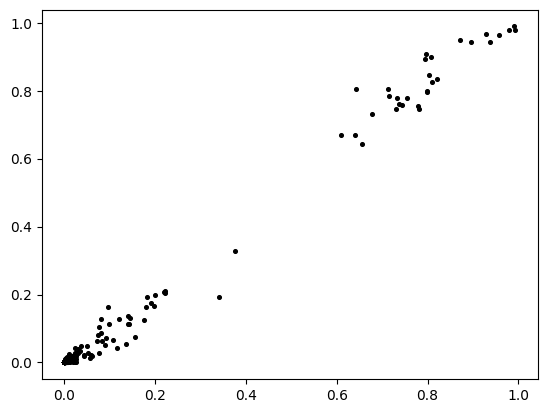

In [38]:
import matplotlib.pyplot as plt
plt.scatter(final_df['overall_pred_run_1'], final_df['overall_pred_run_2'],s=7, color='black')
